<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №2. Краевая задача методом прогонки (потенциал Вудса-Саксона)

**Задача.** Решить краевую задачу для стационарного уравнения с потенциалом
Вудса-Саксона (модельная задача типа уравнения Шрёдингера):

`u'' + q(x)*u = f(x)`, `u(a) = u_a`, `u(b) = u_b`,

где `q(x) = -V0 / (1 + exp((x - R)/γ))` — потенциал Вудса-Саксона.

Нужно:
- решить задачу методом прогонки (метод трёхточечной прогонки для СЛАУ с трёхдиагональной матрицей) для двух разных источников `f(x)`;
- оценить погрешность решения по правилу Рунге, сравнивая решения на сетках с шагом `h` и `h/2`.


In [ ]:
import pandas
import numpy
import scipy
import sympy
import math
import matplotlib.pyplot as plt

In [ ]:
V_0 = 50
R = 0.5
gamma = 2.5
a = 0
b = 10
u_a = 1
u_b = 0

# Потенциал Вудса-Саксона
def q(x):
  return -(V_0)/(1 + numpy.exp((x - R)/(gamma)))

# Источники
def f_1(x):
  return -numpy.sin(x)**3

def f_2(x):
  return 0

In [ ]:
# Метод прогонки
def solve_schrodinger(h, f_func):
  N = int(round((b-a)/h))
  x = numpy.linspace(a, b, N+1)

  # Коэффициенты
  alpha = numpy.zeros(N+1)
  beta = numpy.zeros(N+1)
  u = numpy.zeros(N+1)

  # Прямой ход
  alpha[0] = 0
  beta[0] = u_a
  for i in range(1, N):
    q_i = q(x[i])
    f_i = f_func(x[i])
    denom = 2 + h**2*q_i - alpha[i-1]
    alpha[i] = 1 / denom
    beta[i] = (h **2 * f_i + beta[i-1]) / denom

  # Обратный ход
  u[N] = u_b
  for i in range(N-1, 0, -1):
    u[i] = alpha[i] * u[i + 1] + beta[i]
  u[0] = u_a

  return x, u

In [ ]:
# Решение с разными шагами
h_1 = 0.1 # основной шаг
h_2 = 0.05 # удвоенная точность
x_1, u1_f1 = solve_schrodinger(h_1, f_1)
x_1, u1_f2 = solve_schrodinger(h_1, f_2)
x_2, u2_f1 = solve_schrodinger(h_2, f_1)
x_2, u2_f2 = solve_schrodinger(h_2, f_2)

In [ ]:
# Оценка погрешности (правило Рунге)
# Берём узлы, общие для обеих сеток
error_f1 = numpy.abs(u1_f1 - u2_f1[::2]) / 3
error_f2 = numpy.abs(u1_f2 - u2_f2[::2]) / 3

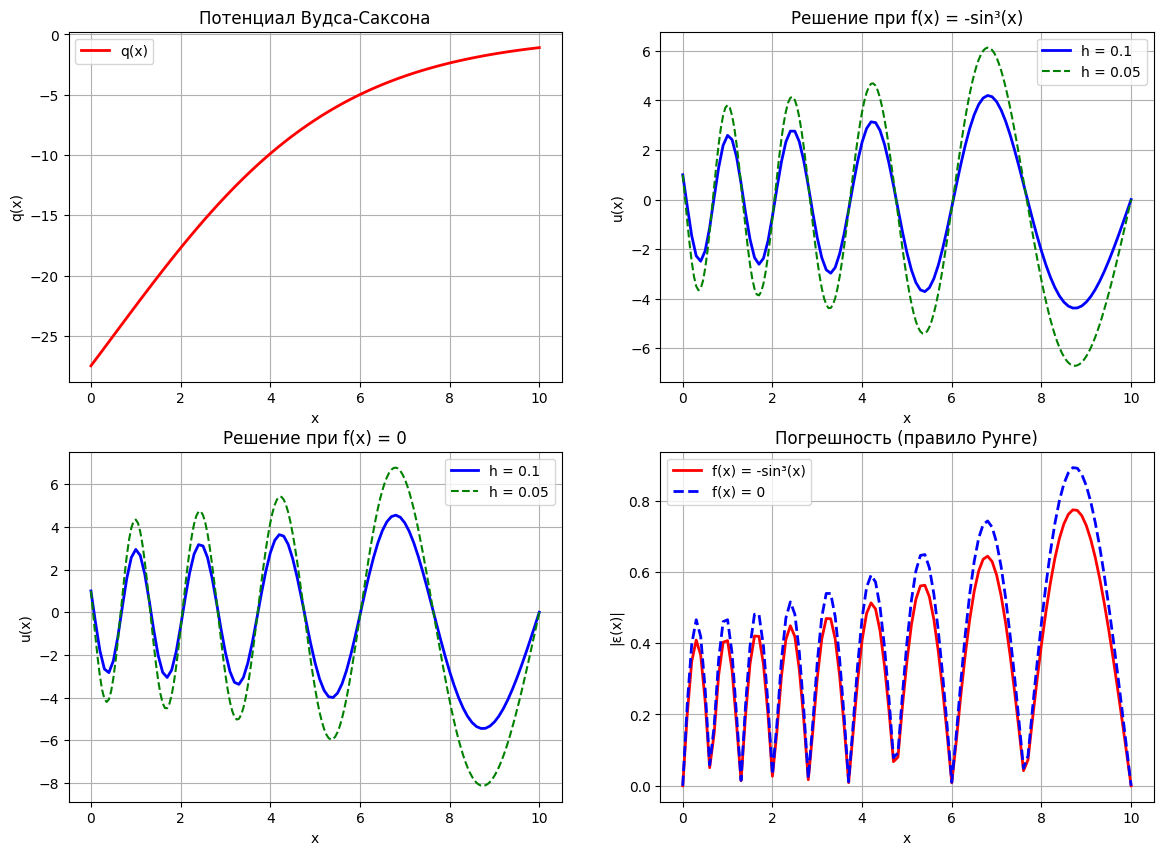

In [ ]:
# Построение графиков
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
# График потенциала
axes[0, 0].plot(x_1, q(x_1), 'r-', linewidth=2, label='q(x)')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('q(x)')
axes[0, 0].set_title('Потенциал Вудса-Саксона')
axes[0, 0].grid(True)
axes[0, 0].legend()

# Решения для f(x) = -sin³(x)
axes[0, 1].plot(x_1, u1_f1, 'b-', linewidth=2, label=f'h = {h_1}')
axes[0, 1].plot(x_2, u2_f1, 'g--', linewidth=1.5, label=f'h = {h_2}')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('u(x)')
axes[0, 1].set_title('Решение при f(x) = -sin³(x)')
axes[0, 1].grid(True)
axes[0, 1].legend()

# Решения для f(x) = 0
axes[1, 0].plot(x_1, u1_f2, 'b-', linewidth=2, label=f'h = {h_1}')
axes[1, 0].plot(x_2, u2_f2, 'g--', linewidth=1.5, label=f'h = {h_2}')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('u(x)')
axes[1, 0].set_title('Решение при f(x) = 0')
axes[1, 0].grid(True)
axes[1, 0].legend()

# Погрешность
x_error = x_1
axes[1, 1].plot(x_error, error_f1, 'r-', linewidth=2, label='f(x) = -sin³(x)')
axes[1, 1].plot(x_error, error_f2, 'b--', linewidth=2, label='f(x) = 0')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('|ε(x)|')
axes[1, 1].set_title('Погрешность (правило Рунге)')
axes[1, 1].grid(True)
axes[1, 1].legend()

In [ ]:
print(f"Потенциал: Вудса-Саксона")
print(f"V0 = {V_0}, R = {R}, γ = {gamma}")
print(f"Отрезок: [{a}, {b}]")
print(f"Шаг h1 = {h_1}, h2 = {h_2}")
print(f"Граничные условия: u({a}) = {u_a}, u({b}) = {u_b}")

print(f"Максимальная погрешность (f = -sin³x): {numpy.max(error_f1):.6e}")
print(f"Максимальная погрешность (f = 0): {numpy.max(error_f2):.6e}")

Потенциал: Вудса-Саксона
V0 = 50, R = 0.5, γ = 2.5
Отрезок: [0, 10]
Шаг h1 = 0.1, h2 = 0.05
Граничные условия: u(0) = 1, u(10) = 0
Максимальная погрешность (f = -sin³x): 7.739041e-01
Максимальная погрешность (f = 0): 8.922904e-01
